# Superdense coding (量子高密度符号化)
Superdense codingは2古典ビットの情報を1量子ビットを用いて量子もつれ状態を消費しながら通信することのできる手法です。

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi

## Superdense codingの実装1
Aliceが2古典ビットの情報をBobに伝えたい状況を考えます。
Aliceのもつ情報が1,0のときのSuperdense codingを実装します。

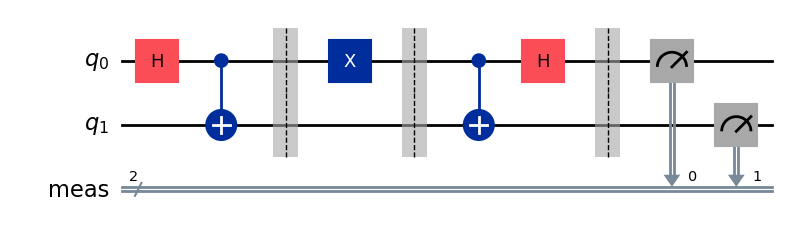

In [ ]:
#Aliceのもつ古典ビット情報
c = "1"
d = "0"

protocol = QuantumCircuit(2)

#AliceとBobにbell状態を共有させる
protocol.h(0)
protocol.cx(0,1)
protocol.barrier()

#Aliceが自身の持つ古典ビットの情報をもとに量子ビットを操作する
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

#Bobの量子ビット操作
protocol.cx(0,1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

Measured 10 with frequency 1024


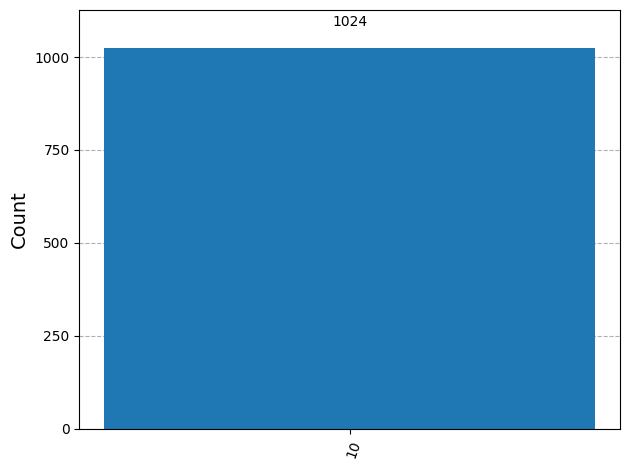

In [ ]:
#AerSimulatorでprotocolを実行する
result = AerSimulator().run(protocol).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

## Superdense condingの実装2
今度はAliceが持っている2bitの情報をランダムに決めます。そして、どんな2bitの情報もAliceからBobに1qubitを用いて通信できることを確認します。
まずはランダムにAliceの2bitの情報を決めます。

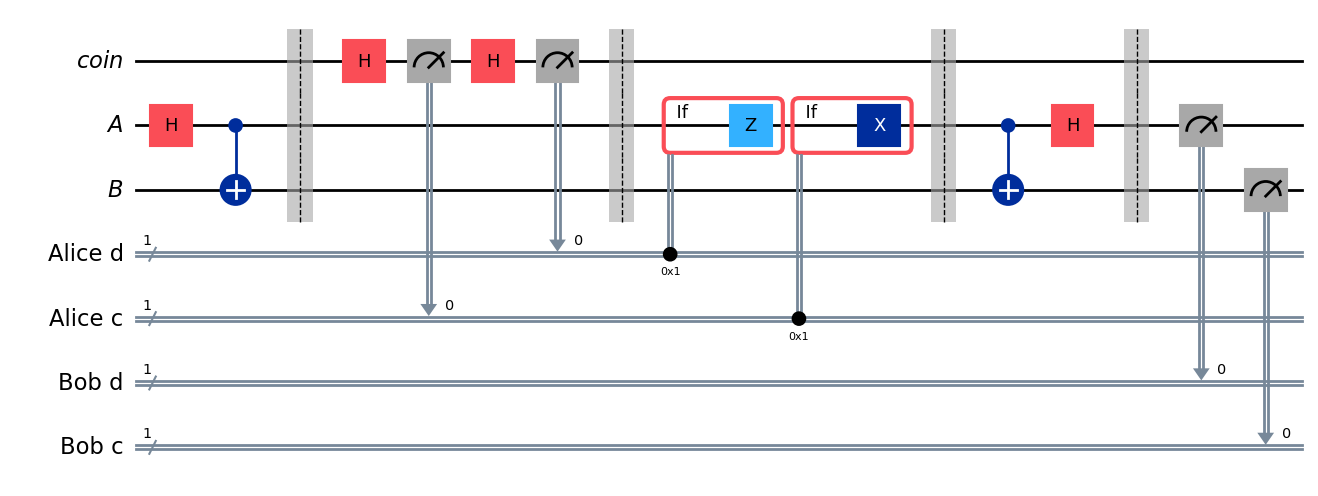

In [8]:
#coinトスをして表と裏を決めるbit
rbg = QuantumRegister(1, "coin")

#量子もつれ状態をAliceとBobに共有させる
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

#Aliceのもつ2古典ビットの情報を保存する古典ビット
Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

#量子もつれ状態の生成
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

#Aliceがもつ古典ビットの情報をランダムに生成する
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

#Aliceがもつ古典ビットの情報をもとに量子ビットの操作
with test.if_test((Alice_d, 1), label = "Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label = "X"):
    test.x(ebit0)
test.barrier()

#Bobの量子ビットの操作
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

#Bobの量子ビットを測定して古典ビットに測定結果を記録する
Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output = "mpl"))



Aliceが持っていた情報とBobが測定した情報が完全に一致していることをシミュレーターで確認します。シミュレーター結果の1,2桁目と3,4桁目が完全に一致していることが2bit通信が完全に成功したことを意味します。

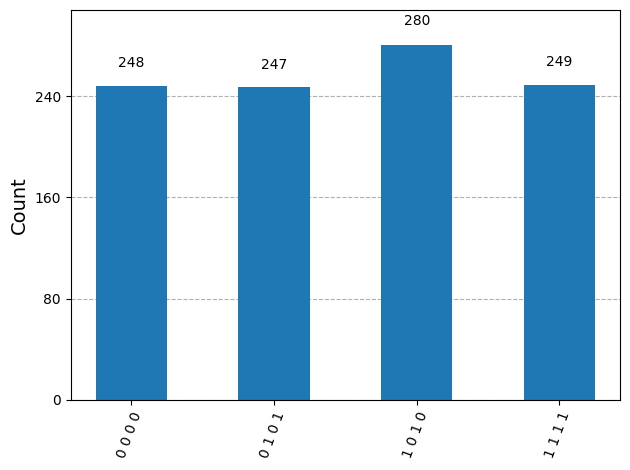

In [9]:
result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))